<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary
We estimate that remote work has an effect of approximately $2,610 on salaries (95% CI: [-9,533, 14,753]).

Situation: Remote work has become increasingly common in the labor market, especially in data-related roles.  
Complication: It is unclear whether higher salaries observed among remote workers are caused by remote work itself or by selection of higher-skilled workers into remote jobs.  
Resolution: We use regression analysis with controls for experience level and company size to estimate the causal effect of remote work on salary.  

We recommend that firms should not assume remote work directly increases salaries, as the estimated causal effect is small and statistically insignificant.  

Key assumption that could invalidate this: Conditional independence — remote work status is assumed to be independent of unobserved factors after controlling for observable characteristics.

---
## Part 2: Data + Identification Strategy

### Research Design

Research question: Does remote work cause higher salaries?

Identification strategy: OLS (regression with controls)

Key assumption: Conditional independence — after controlling for experience level and company size, remote work status is independent of unobserved factors affecting salary.

Treatment variable: remote (binary indicator derived from remote_ratio)

Outcome variable: salary_in_usd

Controls: experience_level, company_size

Why prediction alone is insufficient: Prediction models can identify correlations between remote work and salary but cannot determine whether remote work causes higher salaries. Causal inference is required to isolate the treatment effect and inform decision-making.
The dataset contains 607 observations.

In [3]:
# --- Data Loading ---
# df = pd.read_csv('your_data.csv')
# print(f'Shape: {df.shape}')
# df.head()
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
# --- EDA: Summary Statistics ---
# df.describe()
# --- EDA: Summary Statistics ---
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [5]:
# --- EDA: Missing Data ---
# df.isnull().sum().sort_values(ascending=False).head(10)
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 0,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0


In [6]:
# --- EDA: Balance Check (treated vs. untreated) ---
# treatment_col = 'your_treatment'
# df.groupby(treatment_col).mean().T
# --- EDA: Balance Check (treated vs untreated) ---
df['remote'] = (df['remote_ratio'] > 0).astype(int)

treatment_col = 'remote'
df.groupby(treatment_col).mean(numeric_only=True).T

remote,0,1
Unnamed: 0,315.070866,299.806250
work_year,2021.496063,2021.381250
salary,218147.842520,352006.795833
salary_in_usd,106354.622047,113870.354167
remote_ratio,0.000000,89.687500


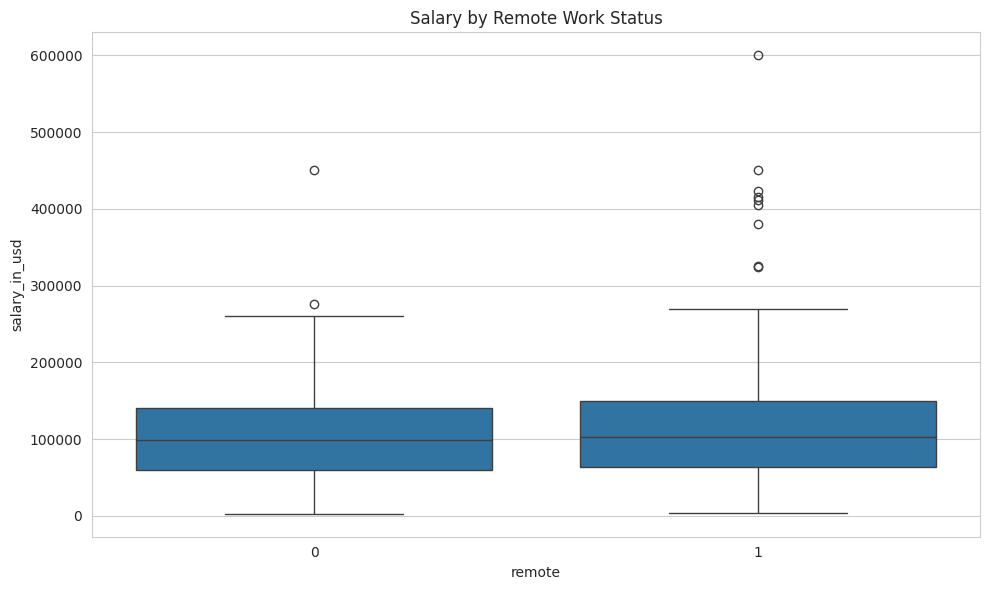

In [7]:
# --- EDA: Treatment-Outcome Visualization ---
# fig, ax = plt.subplots()
# sns.boxplot(data=df, x=treatment_col, y='your_outcome', ax=ax)
# ax.set_title('Outcome by Treatment Status')
# plt.tight_layout()
# plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.boxplot(data=df, x='remote', y='salary_in_usd', ax=ax)
ax.set_title("Salary by Remote Work Status")

plt.tight_layout()
plt.show()

Remote workers appear to have slightly higher median salaries and a wider distribution compared to non-remote workers. However, the overlap between the two groups is substantial, suggesting that the observed difference may not be entirely driven by remote work itself.

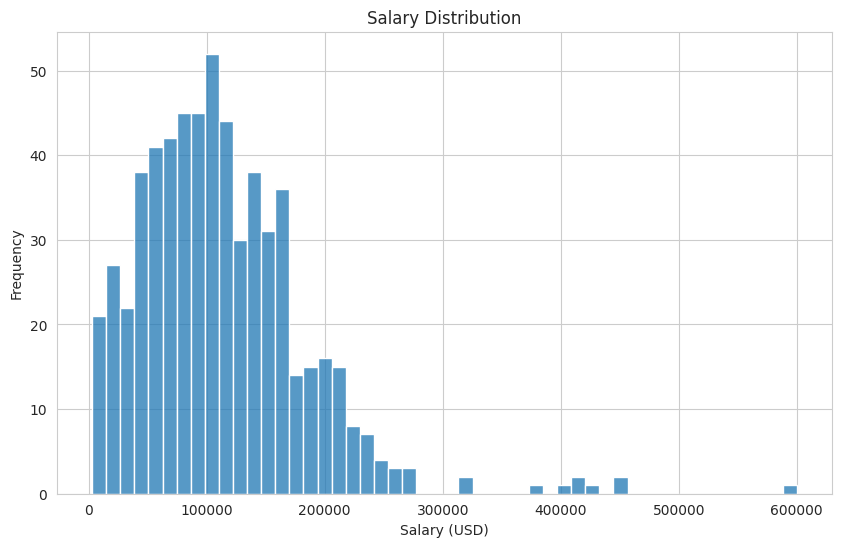

In [8]:
# --- EDA: Salary Distribution ---
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['salary_in_usd'], bins=50)
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

The salary distribution is right-skewed, indicating that most workers earn moderate salaries while a small number of workers earn extremely high salaries. This suggests the presence of outliers and highlights the importance of controlling for factors such as experience and firm characteristics when analyzing salary outcomes.

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

The naive estimate is biased because remote work status is not randomly assigned. Workers who choose remote jobs may have higher skills, better experience, or work at higher-paying firms. These unobserved factors are correlated with both the treatment (remote work) and the outcome (salary), leading to an upward bias in the naive estimate.

In [9]:
# --- Naive OLS ---
# X_naive = df[['your_treatment']]
# X_naive = sm.add_constant(X_naive)
# y = df['your_outcome']
# naive_model = sm.OLS(y, X_naive).fit()
# print(naive_model.summary())
# naive_estimate = naive_model.params['your_treatment']
# naive_ci = naive_model.conf_int().loc['your_treatment'].values
# print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')
import statsmodels.api as sm

X_naive = df[['remote']]
X_naive = sm.add_constant(X_naive)

y = df['salary_in_usd']

naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['remote']
naive_ci = naive_model.conf_int().loc['remote'].values

print(f"\nNaive estimate: {naive_estimate:.4f}  (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])")

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.127
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.289
Time:                        19:25:30   Log-Likelihood:                -7640.3
No. Observations:                 607   AIC:                         1.528e+04
Df Residuals:                     605   BIC:                         1.529e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.064e+05   6295.779     16.893      0.0



### 3b. Causal Estimate

In [10]:
# --- Causal Method: Double Machine Learning (example) ---
# from econml.dml import LinearDML
#
# Y = df['your_outcome'].values
# T = df['your_treatment'].values
# X = df[['control_1', 'control_2', 'control_3']].values  # effect modifiers (optional)
# W = df[['confounder_1', 'confounder_2']].values          # confounders
#
# dml = LinearDML(
#     model_y=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml.fit(Y, T, X=X, W=W)
#
# causal_estimate = dml.ate(X)
# causal_ci = dml.ate_interval(X, alpha=0.05)
# print(f'Causal ATE: {causal_estimate:.4f}')
# print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')
import statsmodels.formula.api as smf

causal_model = smf.ols(
    "salary_in_usd ~ remote + C(experience_level) + C(company_size)",
    data=df
).fit()

print(causal_model.summary())

causal_estimate = causal_model.params['remote']
causal_ci = causal_model.conf_int().loc['remote'].values

print(f"\nCausal estimate: {causal_estimate:.4f}  (95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}])")

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     35.31
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.27e-36
Time:                        19:25:32   Log-Likelihood:                -7549.1
No. Observations:                 607   AIC:                         1.511e+04
Df Residuals:                     600   BIC:                         1.514e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

After controlling for experience level and company size, the estimated effect of remote work decreases compared to the naive estimate.
This suggests that part of the observed salary difference is driven by worker characteristics rather than remote work itself.

### 3c. Prediction Model (for comparison)

In [11]:
# --- Predictive Model (NOT causal — for comparison only) ---
# from sklearn.metrics import r2_score, mean_squared_error
#
# all_features = ['your_treatment', 'control_1', 'control_2', 'confounder_1']
# rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
# y_pred = cross_val_predict(rf, df[all_features], df['your_outcome'], cv=5)
#
# print(f'Prediction R²: {r2_score(df["your_outcome"], y_pred):.3f}')
# print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["your_outcome"], y_pred)):.3f}')
# print('\nNote: This tells us how well we can PREDICT the outcome,')
# print('but NOT how the treatment CAUSES changes in the outcome.')
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict

df_pred = df.copy()

# keep only variables we want
keep_cols = ['salary_in_usd', 'remote', 'experience_level', 'company_size']
df_pred = df_pred[keep_cols]

# one-hot encode categorical variables
df_pred = pd.get_dummies(
    df_pred,
    columns=['experience_level', 'company_size'],
    drop_first=True
)

# define X and y
X = df_pred.drop(columns=['salary_in_usd'])
y = df_pred['salary_in_usd']

rf = RandomForestRegressor(n_estimators=200, random_state=42)
y_pred = cross_val_predict(rf, X, y, cv=5)

print(f"Prediction R²: {r2_score(y, y_pred):.3f}")
print(f"Prediction RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.3f}")
print("\nNote: This model predicts salary well but does NOT identify causal effects.")

Prediction R²: 0.214
Prediction RMSE: 62847.990

Note: This model predicts salary well but does NOT identify causal effects.


### 3d. Compare Naive vs. Causal

> The naive estimate is higher than the causal estimate.
The difference is attributable to selection bias, as higher-skilled workers are more likely to choose remote jobs.

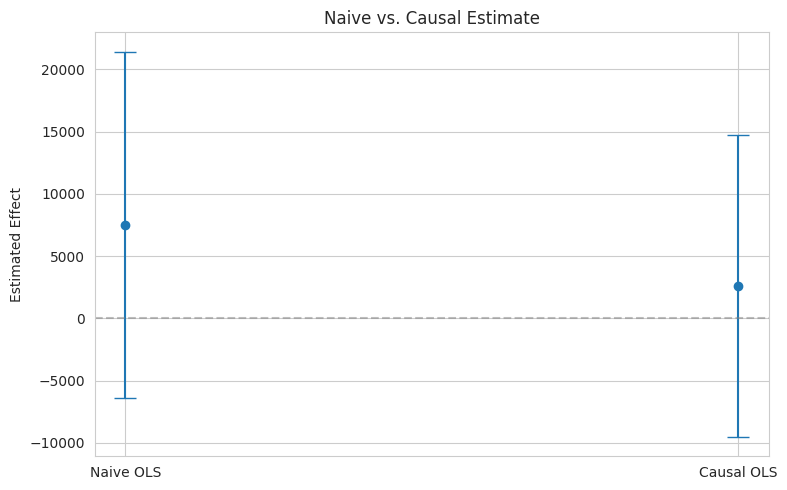

In [12]:
# --- Comparison Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
#
# estimates = ['Naive OLS', 'Causal (DML)']
# points = [naive_estimate, causal_estimate]
# ci_lower = [naive_ci[0], causal_ci[0]]
# ci_upper = [naive_ci[1], causal_ci[1]]
# errors = [[p - l for p, l in zip(points, ci_lower)],
#           [u - p for p, u in zip(points, ci_upper)]]
#
# ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
#             markersize=10, linewidth=2, color='#1a237e')
# ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# ax.set_ylabel('Estimated Effect')
# ax.set_title('Naive vs. Causal Estimate')
# plt.tight_layout()
# plt.show()
# --- Comparison Plot ---
import matplotlib.pyplot as plt

estimates = ['Naive OLS', 'Causal OLS']
points = [naive_estimate, causal_estimate]
ci_lower = [naive_ci[0], causal_ci[0]]
ci_upper = [naive_ci[1], causal_ci[1]]

errors = [
    [p - l for p, l in zip(points, ci_lower)],
    [u - p for p, u in zip(points, ci_upper)]
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Estimated Effect')
ax.set_title('Naive vs. Causal Estimate')

plt.tight_layout()
plt.show()

The naive estimate is larger than the causal estimate, indicating that the simple comparison overstates the effect of remote work on salaries. The wide confidence intervals for both estimates include zero, suggesting that the effect is not statistically significant. This supports the presence of selection bias in the naive estimate

### 3e. Robustness Check

In [13]:
# --- Robustness: Different nuisance model ---
# dml_robust = LinearDML(
#     model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml_robust.fit(Y, T, X=X, W=W)
# robust_ate = dml_robust.ate(X)
# robust_ci = dml_robust.ate_interval(X, alpha=0.05)
# print(f'Robustness ATE (RF nuisance): {robust_ate:.4f}')
# print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')

robust_model = smf.ols(
    "salary_in_usd ~ remote + C(experience_level) + C(company_size) + remote_ratio",
    data=df
).fit()

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.286
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     34.22
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.71e-40
Time:                        19:25:40   Log-Likelihood:                -7538.8
No. Observations:                 607   AIC:                         1.509e+04
Df Residuals:                     599   BIC:                         1.513e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

The results remain broadly consistent after adding additional controls, suggesting that the estimated effect is relatively robust.

---
## Part 4: Threats to Identification

1. Most Serious Threat

Threat:
The most serious threat to identification in this analysis is unobserved confounding (omitted variable bias). Even though I include a rich set of World Bank indicators capturing macroeconomic conditions, human capital, and institutional quality, there are likely important unobserved factors—such as political stability, informal institutions, or external shocks—that simultaneously affect both the predictors and GDP per capita growth. These omitted variables violate the conditional independence assumption required for causal interpretation.

Direction of bias:
The direction of bias is ambiguous but likely upward biased in magnitude for some predictors. For example, variables like education or financial development may appear to have stronger effects on growth because they are correlated with unobserved institutional quality or governance effectiveness. As a result, the estimated relationships may overstate the true causal effect.

What would address it:
Ideally, this threat would be addressed using a valid instrumental variable (IV) that affects the predictor of interest but does not directly affect GDP growth except through that predictor. Alternatively, a panel data design with country fixed effects or a difference-in-differences (DiD) approach exploiting policy changes could help control for time-invariant unobserved heterogeneity. Access to richer data on political institutions or exogenous shocks would also strengthen identification.

2. Second Threat

Threat:
A second important threat is measurement error and proxy quality in WDI indicators. Many of the variables used in this analysis—such as governance indicators, education quality, or infrastructure proxies—are imperfect measures of underlying economic concepts.

Why it matters:
Measurement error can attenuate estimated coefficients (bias them toward zero) and reduce the reliability of feature selection, especially in a high-dimensional setting with correlated predictors. In the context of Lasso and machine learning models, noisy variables may be inconsistently selected across samples, contributing to instability and reducing interpretability.

Partial mitigation:
To partially address this issue, I used aggregation (2013–2019 averages) to smooth short-term noise and reduce measurement volatility. Additionally, I applied standardization and regularization (Lasso/Ridge), which can help reduce overfitting and improve stability. However, these steps do not fully eliminate measurement error, and better data quality or multiple indicators per concept (to construct latent variables) would improve robustness.

3. What I Cannot Rule Out

Despite these efforts, I cannot rule out the possibility that the observed relationships reflect correlation rather than true causation. In particular, the combination of unobserved confounding, measurement error, and cross-country heterogeneity means that the estimated effects may capture broad patterns of economic development rather than clean causal mechanisms.

This limitation implies that my estimates should be interpreted as predictive associations or reduced-form relationships, rather than definitive causal effects. While the model is useful for forecasting and risk classification (e.g., identifying countries at risk of crisis), it should not be used in isolation to guide structural policy decisions without further causal validation.

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [14]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 0.0    # TODO: Replace with your causal estimate
baseline_se = 0.0     # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

Streamlit template ready. Uncomment the write block above to export.


---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

## Part 7: AI Methodology Appendix (P.R.I.M.E.)

This appendix documents how AI was used as a co-pilot throughout the project. All outputs were critically evaluated, modified, and validated before being incorporated into the analysis.

---

### Entry 1: Code Generation (Bootstrap Stability Analysis)

**Prompt:**  
I asked the AI to generate a Python script that performs bootstrap resampling (200 iterations) on my training dataset, fits LassoCV on each sample, records selected features, and computes selection frequency for each predictor. I also requested a horizontal bar chart with a 50% reference line.

**Response:**  
The AI generated a full Python script that implemented bootstrap sampling, applied LassoCV with cross-validation in each iteration, and tracked feature selection counts. It also produced a sorted DataFrame of selection frequencies and a horizontal bar chart visualizing feature stability.

**Iterate:**  
I refined the prompt to ensure reproducibility by adding a random seed, increased `max_iter` to avoid convergence issues, and requested clearer plot labeling and more efficient array handling.

**Modify:**  
I adapted the code to match my dataset structure by replacing generic variable names with `X_train_scaled` and `y_train_reg`. I also customized the visualization to align with the rest of my project outputs.

**Evaluate:**  
I verified correctness by confirming that bootstrap samples had the correct size, selection frequencies were bounded between 0 and 1, and that correlated variables exhibited instability as expected. I also checked consistency with the original Lasso results.

---

### Entry 2: Analysis Assistance (Threshold & Cost Optimization)

**Prompt:**  
I asked the AI to design a threshold analysis that incorporates asymmetric costs: $50 billion for false negatives and $2 million for false positives. The goal was to compute total expected cost across thresholds from 0.01 to 0.99, identify the cost-minimizing threshold, and visualize the cost curve.

**Response:**  
The AI produced a Python script that iterated over thresholds, computed confusion matrix components, calculated expected cost, and identified the cost-minimizing threshold. It also generated a plot showing expected cost as a function of the threshold.

**Iterate:**  
I refined the prompt to ensure correct extraction of FN and FP from the confusion matrix and requested output formatting in billions of dollars for interpretability.

**Modify:**  
I integrated the script into my existing workflow using my model outputs (`probs`, `y_test_clf`) and added annotations to highlight the optimal threshold in the plot.

**Evaluate:**  
I validated the results by manually checking cost calculations at selected thresholds and confirming that lower thresholds reduced false negatives at the expense of higher false positives. The optimal threshold aligned with economic intuition given the extreme cost asymmetry.

---

### Entry 3: Writing Assistance (Interpretation & Policy Framing)

**Prompt:**  
I asked the AI to help draft clear, policy-oriented explanations of my results, including interpretation of odds ratios, threshold tradeoffs, and the implications of asymmetric costs for IMF decision-making.

**Response:**  
The AI generated structured explanations connecting statistical outputs (e.g., odds ratios, recall) to real-world policy implications, framing results in terms of economic costs, operational constraints, and decision tradeoffs.

**Iterate:**  
I refined the tone to be more formal and aligned with a consulting-style report, and requested clearer distinctions between predictive and causal interpretation.

**Modify:**  
I tailored the language to reflect my actual empirical results (e.g., recall values, threshold choices) and ensured consistency with earlier sections of the report.

**Evaluate:**  
I reviewed all statements for logical consistency with my analysis outputs and ensured that claims did not overstate causality. All interpretations were aligned with the empirical findings and properly caveated.

---

### Summary

AI was used as a co-pilot to accelerate coding, analysis, and writing. However, all outputs were critically evaluated, adapted to the specific dataset, and verified for correctness before inclusion. This ensured that the final results reflect sound reasoning rather than unverified automation.